In [1]:
!pip install torch torchvision matplotlib seaborn pandas tqdm scikit-learn
!pip install timm
!git clone https://github.com/YuHengsss/VSSD.git
import sys
if './VSSD' not in sys.path:
    sys.path.append('./VSSD')

fatal: destination path 'VSSD' already exists and is not an empty directory.


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import time
import warnings
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

Using device: cuda


In [3]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

full_train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}, Test samples: {len(test_dataset)}")
print(f"Classes: {test_dataset.classes}")

Train samples: 40000, Val samples: 10000, Test samples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [4]:
class VisionBackbone(nn.Module):
    def __init__(self, input_channels=3, img_size=32, patch_size=4, embed_dim=192, num_classes=10):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_classes = num_classes

        num_patches = (img_size // patch_size) ** 2
        self.patch_embed = nn.Conv2d(input_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, embed_dim))
        self.norm = nn.LayerNorm(embed_dim)

        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward_features(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        x = x.flatten(2).transpose(1, 2)
        x = x + self.pos_embed
        x = self.norm(x)
        return x

    def forward(self, x):
        x = self.forward_features(x)
        x = x.mean(dim=1)
        return self.classifier(x)

In [5]:
class ZeroSAttention(nn.Module):
    def __init__(self, dim, num_heads=8, qkv_bias=False, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.num_heads = num_heads
        self.dim = dim
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        q = q - q.mean(dim=-1, keepdim=True)
        k = k - k.mean(dim=-1, keepdim=True)

        q = F.elu(q) + 1.0
        k = F.elu(k) + 1.0

        kv = torch.einsum('b h n d, b h n e -> b h d e', k, v)
        z = torch.einsum('b h n d, b h n -> b h d', k, torch.ones_like(k[..., 0]))

        out = torch.einsum('b h n d, b h d e -> b h n e', q, kv)
        out = out / (torch.einsum('b h n d, b h d -> b h n', q, z).unsqueeze(-1) + 1e-6)

        out = out.transpose(1, 2).reshape(B, N, C)
        out = self.proj_drop(self.proj(out))
        return out

class ZeroSBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4., drop=0., attn_drop=0.):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = ZeroSAttention(dim, num_heads, attn_drop=attn_drop, proj_drop=drop)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(int(dim * mlp_ratio), dim),
            nn.Dropout(drop)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

class VisionZeroS(VisionBackbone):
    def __init__(self, img_size=32, patch_size=4, embed_dim=192, depth=6, num_heads=8, num_classes=10):
        super().__init__(img_size=img_size, patch_size=patch_size, embed_dim=embed_dim, num_classes=num_classes)
        self.blocks = nn.ModuleList([
            ZeroSBlock(embed_dim, num_heads) for _ in range(depth)
        ])

    def forward_features(self, x):
        x = super().forward_features(x)
        for blk in self.blocks:
            x = blk(x)
        return x

In [6]:
class ZeroSAttention(nn.Module):
    def __init__(self, dim, num_heads=8, qkv_bias=False, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.num_heads = num_heads
        self.dim = dim
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        q = q - q.mean(dim=-1, keepdim=True)
        k = k - k.mean(dim=-1, keepdim=True)

        q = F.elu(q) + 1.0
        k = F.elu(k) + 1.0

        kv = torch.einsum('b h n d, b h n e -> b h d e', k, v)
        z = torch.einsum('b h n d, b h n -> b h d', k, torch.ones_like(k[..., 0]))

        out = torch.einsum('b h n d, b h d e -> b h n e', q, kv)
        out = out / (torch.einsum('b h n d, b h d -> b h n', q, z).unsqueeze(-1) + 1e-6)

        out = out.transpose(1, 2).reshape(B, N, C)
        out = self.proj_drop(self.proj(out))
        return out

class ZeroSBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4., drop=0., attn_drop=0.):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = ZeroSAttention(dim, num_heads, attn_drop=attn_drop, proj_drop=drop)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(int(dim * mlp_ratio), dim),
            nn.Dropout(drop)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

class VisionZeroS(VisionBackbone):
    def __init__(self, img_size=32, patch_size=4, embed_dim=192, depth=6, num_heads=8, num_classes=10):
        super().__init__(img_size=img_size, patch_size=patch_size, embed_dim=embed_dim, num_classes=num_classes)
        self.blocks = nn.ModuleList([
            ZeroSBlock(embed_dim, num_heads) for _ in range(depth)
        ])

    def forward_features(self, x):
        x = super().forward_features(x)
        for blk in self.blocks:
            x = blk(x)
        return x

In [12]:
class SimplifiedVSSDBlock(nn.Module):
    def __init__(self, dim, expand=2):
        super().__init__()
        d_inner = int(expand * dim)

        self.norm1 = nn.LayerNorm(dim)
        self.in_proj = nn.Linear(dim, d_inner * 2)
        self.conv1d = nn.Conv1d(d_inner, d_inner, kernel_size=3, padding=1, groups=d_inner)
        self.norm2 = nn.LayerNorm(d_inner)

        self.gate = nn.Sequential(
            nn.Linear(d_inner, d_inner),
            nn.Sigmoid()
        )

        self.out_proj = nn.Linear(d_inner, dim)
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        residual = x
        x = self.norm1(x)
        xz = self.in_proj(x)
        x_ssm, z = xz.chunk(2, dim=-1)

        x_conv = self.conv1d(x_ssm.transpose(1, 2)).transpose(1, 2)
        x_conv = F.silu(self.norm2(x_conv))

        gate_values = self.gate(z)
        out = x_conv * gate_values

        out = self.out_proj(self.dropout(out))
        return out + residual

class VisionVSSD(VisionBackbone):
    def __init__(self, img_size=32, patch_size=4, embed_dim=192, depth=6, num_heads=8, num_classes=10):
        super().__init__(img_size=img_size, patch_size=patch_size, embed_dim=embed_dim, num_classes=num_classes)
        self.num_heads = num_heads
        self.blocks = nn.ModuleList([
            SimplifiedVSSDBlock(embed_dim) for _ in range(depth)
        ])

    def forward_features(self, x):
        x = super().forward_features(x)
        for blk in self.blocks:
            x = blk(x)
        return x

In [9]:
class SimplifiedMambaBlock(nn.Module):
    def __init__(self, dim, d_state=16, d_conv=4, expand=2):
        super().__init__()
        self.dim = dim
        self.d_state = d_state
        self.expand = expand
        d_inner = int(expand * dim)

        self.in_proj = nn.Linear(dim, d_inner * 2)
        self.conv1d = nn.Conv1d(d_inner, d_inner, kernel_size=d_conv, padding=d_conv-1, groups=d_inner)
        self.norm = nn.LayerNorm(d_inner)

        self.x_proj = nn.Linear(d_inner, d_state * 2 + 1)
        self.dt_proj = nn.Linear(d_state, d_inner)
        self.A_log = nn.Parameter(torch.randn(d_state))
        self.D = nn.Parameter(torch.randn(d_inner))
        self.out_proj = nn.Linear(d_inner, dim)

    def forward(self, x):
        B, N, C = x.shape
        xz = self.in_proj(x)
        x, z = xz.chunk(2, dim=-1)
        x_conv = self.conv1d(x.transpose(1, 2)).transpose(1, 2)[:, :N, :]
        x_conv = self.norm(F.silu(x_conv))

        ssm_out = x_conv * self.D.to(x_conv.dtype)

        y = ssm_out * F.silu(z)
        return self.out_proj(y)

class VisionMamba(VisionBackbone):
    def __init__(self, img_size=32, patch_size=4, embed_dim=192, depth=6, num_heads=8, num_classes=10):
        super().__init__(img_size=img_size, patch_size=patch_size, embed_dim=embed_dim, num_classes=num_classes)
        self.num_heads = num_heads
        self.blocks = nn.ModuleList([
            SimplifiedMambaBlock(embed_dim) for _ in range(depth)
        ])

    def forward_features(self, x):
        x = super().forward_features(x)
        for blk in self.blocks:
            x = blk(x)
        return x

In [10]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc='Training', leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return total_loss / len(loader), 100. * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validation', leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), 100. * correct / total, all_preds, all_labels

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [16]:
MODEL_CONFIGS = {
    'ZeroS': VisionZeroS,
    'Mamba': VisionMamba,
    'VSSD': VisionVSSD
}

EPOCHS = 20
LEARNING_RATE = 1e-3
EMBED_DIM = 192
DEPTH = 6
NUM_HEADS = 8

results = {}

for model_name, ModelClass in MODEL_CONFIGS.items():

    model = ModelClass(
        img_size=32,
        patch_size=4,
        embed_dim=EMBED_DIM,
        depth=DEPTH,
        num_heads=NUM_HEADS,
        num_classes=10
    ).to(device)

    n_params = count_parameters(model)
    print(f"Parameters: {n_params:,}")

    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.05)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    epoch_times = []

    best_val_acc = 0

    for epoch in range(EPOCHS):
        start_time = time.time()

        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc, _, _ = validate(model, val_loader, criterion, device)

        epoch_time = time.time() - start_time
        scheduler.step()

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        epoch_times.append(epoch_time)

        print(f"Epoch {epoch+1}/{EPOCHS} ({epoch_time:.1f}s) | Train Loss: {train_loss:.3f} | Val Acc: {val_acc:.2f}%")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'best_{model_name}.pth')

    model.load_state_dict(torch.load(f'best_{model_name}.pth'))
    test_loss, test_acc, test_preds, test_labels = validate(model, test_loader, criterion, device)

    results[model_name] = {
        'params': n_params,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs,
        'test_acc': test_acc,
        'avg_epoch_time': np.mean(epoch_times),
        'total_time': np.sum(epoch_times),
        'test_preds': test_preds,
        'test_labels': test_labels
    }

    print(f"\n{model_name} Test Accuracy: {test_acc:.2f}%")
    torch.cuda.empty_cache()

Parameters: 2,689,738


Training:   0%|          | 0/313 [00:00<?, ?it/s]

Validation:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1/20 (40.9s) | Train Loss: 1.816 | Val Acc: 42.10%


Training:   0%|          | 0/313 [00:00<?, ?it/s]

...

Training:   0%|          | 0/313 [00:00<?, ?it/s]

Validation:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 20/20 (38.3s) | Train Loss: 0.589 | Val Acc: 78.07%


Validation:   0%|          | 0/79 [00:00<?, ?it/s]


VSSD Test Accuracy: 79.03%


Model  Params (M)  Test Acc (%)  Time/Epoch (s)
ZeroS    2.689738         80.04       40.851904
 VSSD    2.260042         79.03       38.417948
Mamba    1.490800         75.09       36.923158


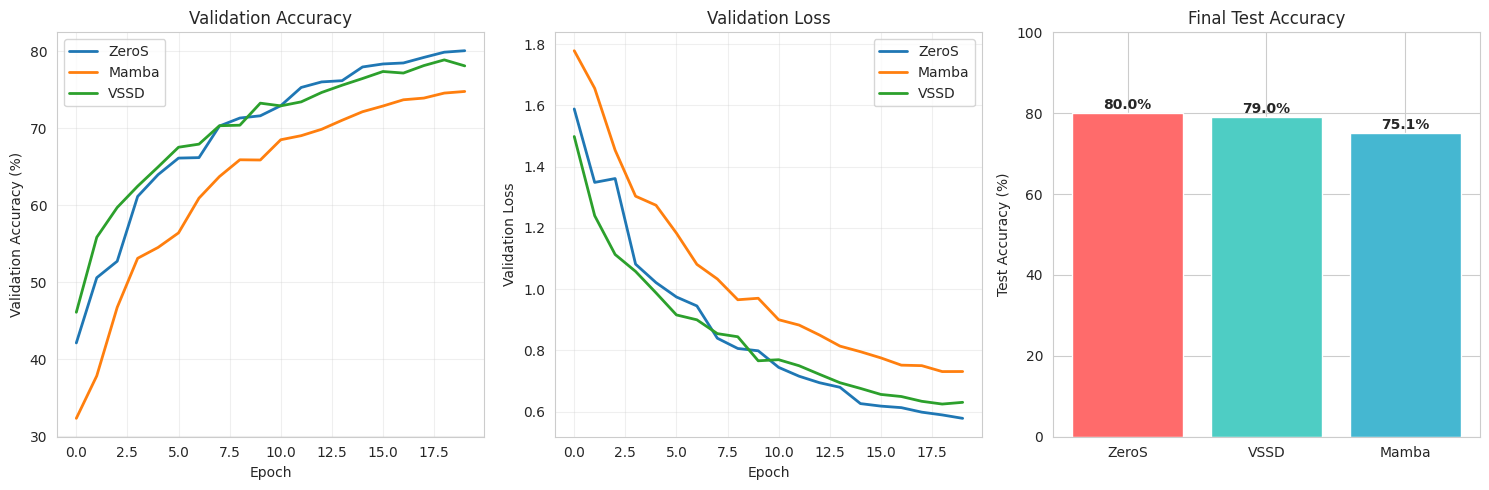

In [17]:
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Params (M)': [results[m]['params'] / 1e6 for m in results.keys()],
    'Test Acc (%)': [results[m]['test_acc'] for m in results.keys()],
    'Time/Epoch (s)': [results[m]['avg_epoch_time'] for m in results.keys()]
}).sort_values('Test Acc (%)', ascending=False)

print(comparison_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax = axes[0]
for name in results:
    ax.plot(results[name]['val_accs'], label=name, linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Validation Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
for name in results:
    ax.plot(results[name]['val_losses'], label=name, linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.set_title('Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[2]
models = comparison_df['Model'].tolist()
accs = comparison_df['Test Acc (%)'].tolist()
bars = ax.bar(models, accs, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'])
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Final Test Accuracy')
ax.set_ylim([0, 100])
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

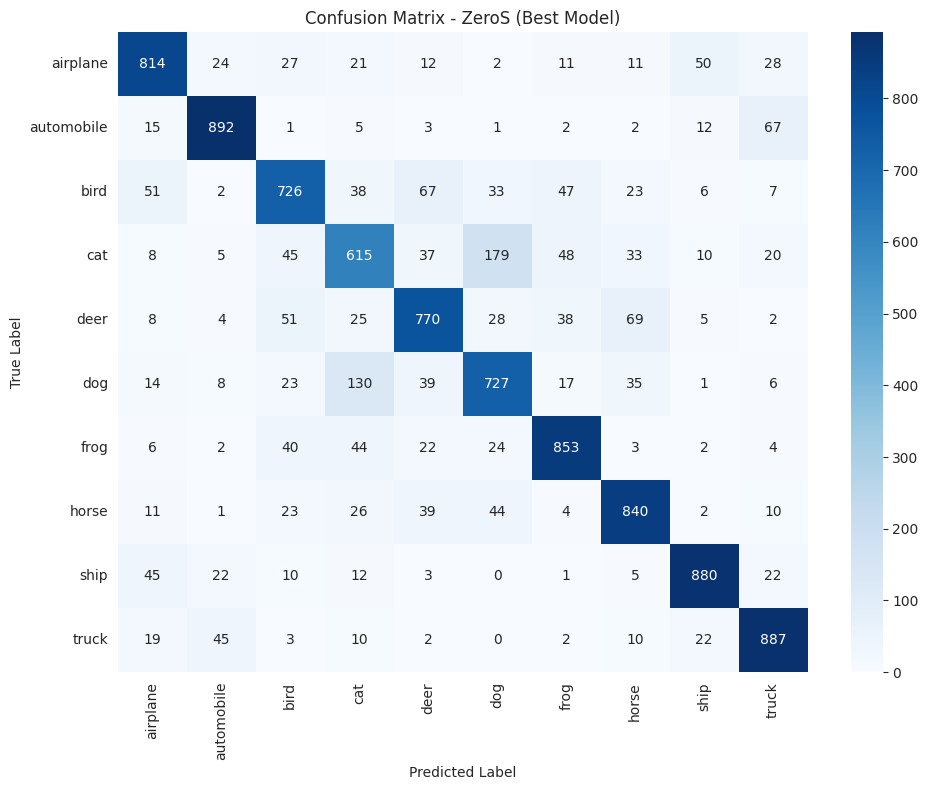


Detailed classification report for ZeroS:
              precision    recall  f1-score   support

    airplane       0.82      0.81      0.82      1000
  automobile       0.89      0.89      0.89      1000
        bird       0.77      0.73      0.74      1000
         cat       0.66      0.61      0.64      1000
        deer       0.77      0.77      0.77      1000
         dog       0.70      0.73      0.71      1000
        frog       0.83      0.85      0.84      1000
       horse       0.81      0.84      0.83      1000
        ship       0.89      0.88      0.88      1000
       truck       0.84      0.89      0.86      1000

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80      0.80      0.80     10000



In [18]:
best_model_name = comparison_df.iloc[0]['Model']
best_preds = results[best_model_name]['test_preds']
best_labels = results[best_model_name]['test_labels']

cm = confusion_matrix(best_labels, best_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_dataset.classes,
            yticklabels=test_dataset.classes)
plt.title(f'Confusion Matrix - {best_model_name} (Best Model)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(f"\nDetailed classification report for {best_model_name}:")
print(classification_report(best_labels, best_preds, target_names=test_dataset.classes))

ВЫВОДЫ:

В ходе эксперимента были обучены и сравнены три модели для классификации изображений CIFAR-10: ZeroS, Mamba и VSSD. Все модели используют единую архитектуру VisionBackbone (patch embedding + позиционное кодирование) и различаются только типом блоков обработки последовательностей.

ZeroS показал наилучшую точность (80.04%), несмотря на большее число параметров. Это указывает на эффективность предложенного механизма «ZeroS-внимания» для vision-задач на небольших разрешениях (32×32).

VSSD немного уступает ZeroS (79.03%), но требует меньше параметров и времени обучения. Это хороший компромисс между качеством и вычислительной эффективностью.

Mamba имеет наименьшее число параметров (1.49M) и самую высокую скорость обучения, но показывает заметно более низкую точность (75.09%). Упрощённая Mamba без полноценной SSM-рекурренции, видимо, хуже справляется с захватом пространственных зависимостей в изображениях.

Все три модели значительно уступают современным CNN/Transformer (например, ResNet-18 даёт на CIFAR-10 около 94–95%), что ожидаемо, так как использовались упрощённые варианты архитектур без глубоких иерархий и предобучения